In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
# 1. DOWNLOAD AND LOAD DATASET
path = kagglehub.dataset_download("amisha0528/mall-customers-dataset")
csv_path = os.path.join(path, "Mall_Customers.csv")
df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'mall-customers-dataset' dataset.


In [6]:
# 2. DATA PREPROCESSING
# Selecting Annual Income and Spending Score for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling is crucial for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

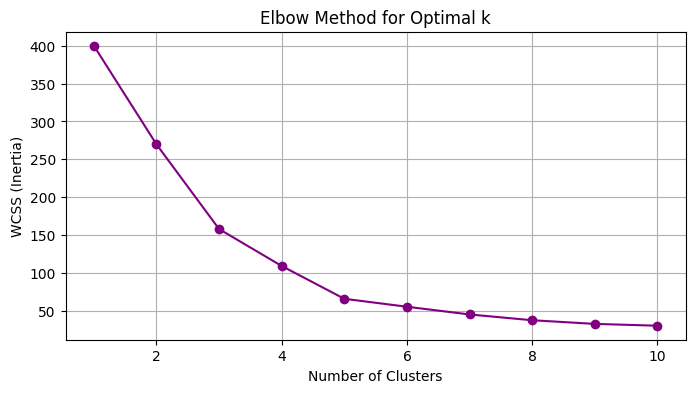

In [7]:
# 3. ELBOW METHOD (To find optimal clusters)
wcss = []
for i in range(1, 11):
    # FIXED: changed n_components to n_clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='purple')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()


In [8]:
# 4. APPLY K-MEANS (Using k=5 based on standard mall dataset results)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [9]:
# 5. PCA FOR VISUALIZATION
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

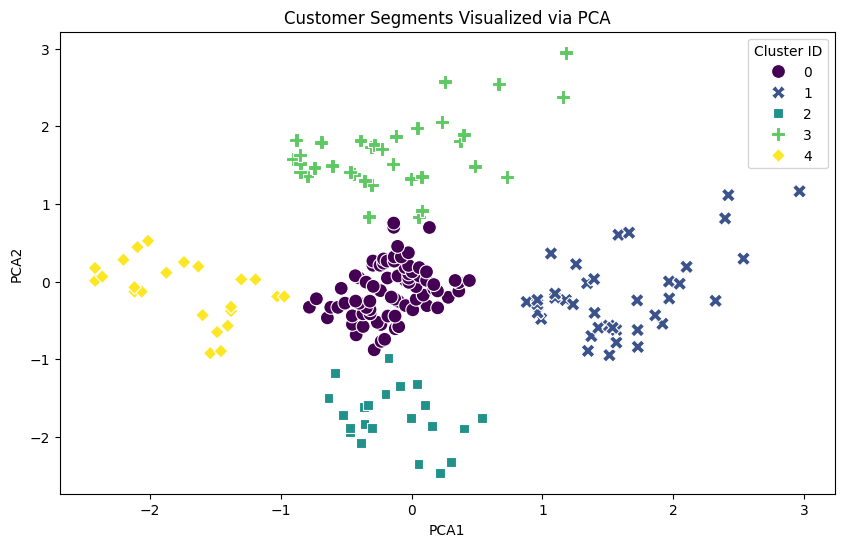

In [10]:
# 6. VISUALIZE SEGMENTS
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis', s=100, style='Cluster')
plt.title('Customer Segments Visualized via PCA')
plt.legend(title='Cluster ID')
plt.show()

In [11]:

# 7. FINAL INSIGHTS (Grouped by Cluster)
print("\n--- Cluster Analysis Summary ---")
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(summary)


--- Cluster Analysis Summary ---
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043
